Files loaded successfully!

=== Performance Comparison (Post-2022) ===
Metric               | Enhanced OLS    | Optimized RF   
-------------------------------------------------------
Mean Monthly Return  | 2.0069%         | 1.8367%
Monthly Volatility   | 10.0464%         | 5.2718%
Annualized Sharpe    | 0.6920          | 1.2069
Monthly Win Rate     | 57.45%          | 72.34%


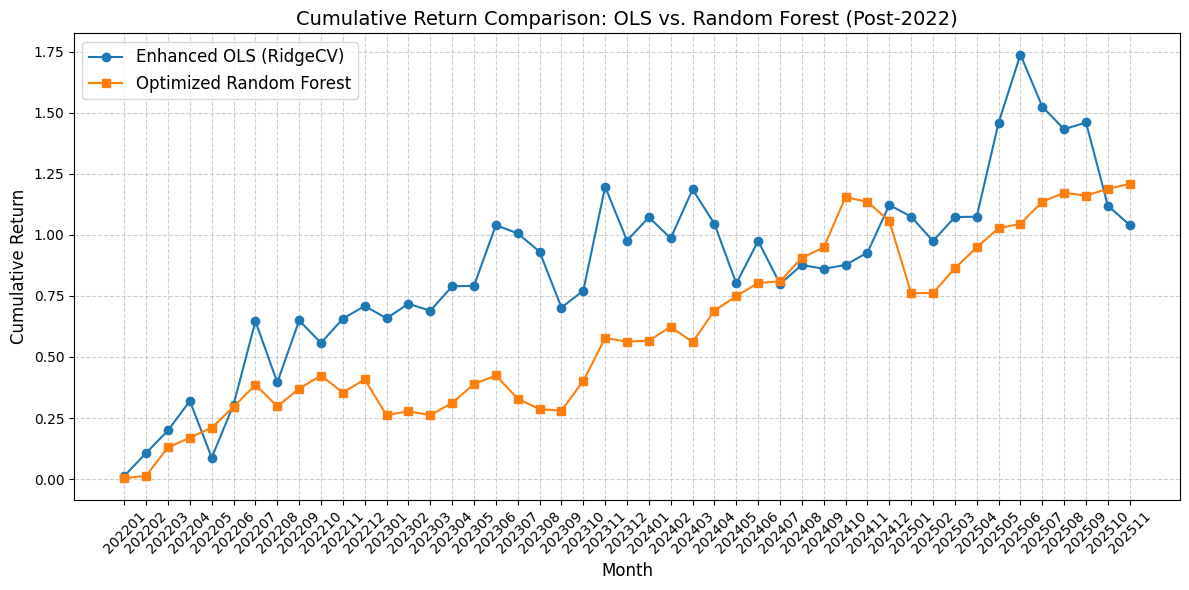

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Load the Top 6 Portfolio Selections
# =========================
# Note: Loading the updated files based on your directory screenshot
try:
    top6_ols = pd.read_csv("new_ols_ridgecv_top6_by_month_post2022.csv")
    top6_rf = pd.read_csv("rf_top6_by_month_post2022.csv")
    print("Files loaded successfully!\n")
except FileNotFoundError:
    print("File not found. Please check your data directory path.")

# =========================
# 2. Calculate Actual Portfolio Returns (Equal-weighted)
# =========================
# Group by month (DateKey) and calculate the mean of the actual next-month returns (y_next)
ols_portfolio = top6_ols.groupby("DateKey")["y_next"].mean().reset_index()
rf_portfolio = top6_rf.groupby("DateKey")["y_next"].mean().reset_index()

# Rename columns for clarity before merging
ols_portfolio.rename(columns={"y_next": "OLS_Return"}, inplace=True)
rf_portfolio.rename(columns={"y_next": "RF_Return"}, inplace=True)

# Merge both portfolios on the DateKey
portfolio_compare = pd.merge(ols_portfolio, rf_portfolio, on="DateKey")

# =========================
# 3. Calculate Core Performance Metrics
# =========================
# Annualization factor for monthly data
annual_factor = 12

# Mean monthly return
ols_mean = portfolio_compare["OLS_Return"].mean()
rf_mean = portfolio_compare["RF_Return"].mean()

# Monthly volatility (Standard Deviation as Risk)
ols_std = portfolio_compare["OLS_Return"].std()
rf_std = portfolio_compare["RF_Return"].std()

# Annualized Sharpe Ratio (Assuming Risk-Free Rate = 0 for relative comparison)
ols_sharpe = (ols_mean / ols_std) * np.sqrt(annual_factor)
rf_sharpe = (rf_mean / rf_std) * np.sqrt(annual_factor)

# Win Rate (Percentage of months with positive returns)
ols_win_rate = (portfolio_compare["OLS_Return"] > 0).mean()
rf_win_rate = (portfolio_compare["RF_Return"] > 0).mean()

# Print the performance summary
print("=== Performance Comparison (Post-2022) ===")
print(f"{'Metric':<20} | {'Enhanced OLS':<15} | {'Optimized RF':<15}")
print("-" * 55)
print(f"{'Mean Monthly Return':<20} | {ols_mean:.4%}         | {rf_mean:.4%}")
print(f"{'Monthly Volatility':<20} | {ols_std:.4%}         | {rf_std:.4%}")
print(f"{'Annualized Sharpe':<20} | {ols_sharpe:.4f}          | {rf_sharpe:.4f}")
print(f"{'Monthly Win Rate':<20} | {ols_win_rate:.2%}          | {rf_win_rate:.2%}")

# =========================
# 4. Plot Cumulative Returns
# =========================
# Calculate cumulative returns: (1 + r1) * (1 + r2) ... - 1
portfolio_compare["OLS_Cum"] = (1 + portfolio_compare["OLS_Return"]).cumprod() - 1
portfolio_compare["RF_Cum"] = (1 + portfolio_compare["RF_Return"]).cumprod() - 1

# Convert DateKey to string for better x-axis formatting
portfolio_compare["DateStr"] = portfolio_compare["DateKey"].astype(str)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(portfolio_compare["DateStr"], portfolio_compare["OLS_Cum"], label="Enhanced OLS (RidgeCV)", marker='o', linestyle='-')
plt.plot(portfolio_compare["DateStr"], portfolio_compare["RF_Cum"], label="Optimized Random Forest", marker='s', linestyle='-')

# Add titles, labels, and styling
plt.title("Cumulative Return Comparison: OLS vs. Random Forest (Post-2022)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Cumulative Return", fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()